# ENGR 1451/2451 — Weekly Assignment 4
**10 points**

This assignment applies measurement-error ideas, pandas data manipulation, and scatterplots and time trends.

**Due:** See Canvas.

Complete the work directly in this notebook. Show your Python code and give brief written explanations where requested.

## What to hand in

Work this assignment with the **course tutor** in the class project. Use the course tutor as your AI help for this assignment; it keeps the record for you, so you do not need to write a separate log.

At the end of each working session, type **"make my record"** in the chat. Copy the block it produces and paste it into the **Session records** cell near the bottom of this notebook.

You do not have to finish in one sitting. To continue later, start a new chat in the same project, state which assignment you are working on and where you stopped, and continue from there. Paste the new session record below the previous one.

Session records are not graded for correctness or for how much help you needed. The code and written answers must still be your own.

## Setup

All data are synthetic teaching examples. LE4-1 and LE4-2 use data embedded in this notebook.
For LE4-3 and LE4-4, place the supplied `buildings.csv` file in a `data/` subfolder beside this notebook:

```text
LE04.ipynb
data/
    buildings.csv
```

Run the notebook with its containing folder as the working directory so that
`data/buildings.csv` points to the supplied file.

Use sample standard deviation $s$ (`ddof=1`). Select rows by conditions, not row positions,
and calculate counts and the latest year from the data. Use the supplied settings for thresholds.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm

## LE4-1. Comparing two measuring instruments (2 pts)

Two instruments repeatedly measure the same reference block. Treat its certified length,
**25.000 mm**, as exact for this exercise.

### A. Precision and estimated bias (1 pt)

Create a table showing the **mean**, **sample standard deviation**, and **estimated bias**
for each instrument. Here, estimated bias is the sample mean minus the reference length.
Which instrument is more precise? Which sample mean is closer to the reference?

**Answer:**

In [2]:
reference_mm = 25.000
calibration = pd.DataFrame({
    "A_mm": [25.12, 25.10, 25.14, 25.11, 25.13,
             25.09, 25.12, 25.11, 25.13, 25.10],
    "B_mm": [24.92, 25.06, 24.97, 25.12, 24.89,
             25.03, 25.08, 24.95, 25.00, 24.98],
})

means = calibration.mean()
bias = means - reference_mm
print(means)
# Your summary table here. Report lengths, s, and estimated bias in mm.
summary = pd.DataFrame({
    "mean [mm]": means,
    "bias [mm]": bias,
    "sample std [mm]": calibration.std(ddof = 1).round(3) #standard deviation decimal places should reflect measurement precision
})
display(summary)

A_mm    25.115
B_mm    25.000
dtype: float64


,mean [mm],bias [mm],sample std [mm]
A_mm,25.115,0.115,0.016
B_mm,25.000,0.000,0.073


Instrument A is more precise because the standard deviation is smaller, meaning less variation in measurements. However instrument B is more accurate because the center of data for measurements is closer to the true reference value of 25 mm.

### B. Apply a calibration correction (1 pt)

Subtract A's estimated bias from every A reading and store the result in `corrected_A`.
Compare its mean and sample $s$ with the original A readings.

What changed, and what stayed the same? Would simply collecting more **uncorrected**
readings remove a persistent bias?

**Answer:** The mean changed to 25, the bias went to 0, and the standard deviation stayed the same. This reflected the fact that shifting the data up or down will shift the mean by the same amount, but the stardard deviation remains the same. Collecting more uncorrected readings does not remove the bias. More readings only 'evens out' to a reference value if there is no bias.

In [3]:
# Your correction and comparison here
corrected_A = calibration["A_mm"] - bias[0]
print(corrected_A.mean() - reference_mm)

corrected_A_mean = corrected_A.mean()
corrected_A_bias = corrected_A.mean() - reference_mm
corrected_A_std = corrected_A.std(ddof = 1)
#add new row to summary table for bias-corrected instrument A
summary.loc["corrected A"] = [corrected_A_mean, corrected_A_bias, corrected_A_std]
display(summary)

0.0


,mean [mm],bias [mm],sample std [mm]
A_mm,25.115,0.115,0.016000
B_mm,25.000,0.000,0.073000
corrected A,25.000,0.000,0.015811


## LE4-2. Investigating unusual resistance readings (3 pts)

An instrument repeatedly measures the same nominal 100-ohm resistor under stable conditions.
Its exact resistance is unknown. An independent equipment log documents a **loose electrical
lead during one reading**; the other readings have no documented fault.

### A. Flag observations for investigation (1 pt)

Calculate $Q_1$, $Q_3$, and the IQR. Flag readings outside
$[Q_1-1.5\,\mathrm{IQR},\ Q_3+1.5\,\mathrm{IQR}]$ with a Boolean mask called `is_outlier`.
Display their reading IDs, resistance values, and log status. Use `.loc[]` and retain the original data.

In [4]:
resistance_values = np.array([
    100.1, 99.9, 100.0, 100.2, 100.1, 99.8, 100.0, 100.1, 102.4, 99.9,
    100.2, 100.0, 99.8, 100.1, 100.0, 100.2, 100.1, 101.1, 99.9, 100.0,
])
log_status = [
    "none", "none", "none", "none", "none", "none", "none", "none", "loose_lead", "none",
    "none", "none", "none", "none", "none", "none", "none", "none", "none", "none",
]
readings = pd.DataFrame({
    "reading_id": [f"R{number:02d}" for number in range(1, len(resistance_values) + 1)],
    "resistance_ohm": resistance_values,
    "log_status": log_status,
})
resistance_settings = {
    "outlier_multiplier": 1.5,
    "fault_status": "loose_lead",
    "lower_ohm": 99.8,
    "upper_ohm": 100.2,
}

# Your IQR calculation, Boolean mask, and flagged-reading table here
q1 = np.quantile(resistance_values, 0.25)
q3 = np.quantile(resistance_values, 0.75)
iqr = q3 - q1
median = np.quantile(resistance_values, 0.5)
lower = q1 - iqr*resistance_settings["outlier_multiplier"]
upper = q3 + iqr*resistance_settings["outlier_multiplier"]

is_outlier = (resistance_values > upper) | (resistance_values < lower)
print(is_outlier) #printed for debugging
flagged_readings = readings.loc[is_outlier]
display(flagged_readings)

[False False False False False False False False  True False False False
 False False False False False  True False False]


,reading_id,resistance_ohm,log_status
8,R09,102.4,loose_lead
17,R18,101.1,none


### B. Exclude a documented failure (1 pt)

Create `retained_readings` by excluding **only the reading with the logged loose lead**.
Select it by `log_status`, not by its row position or resistance value.
Compare the count, mean, and sample $s$ for all readings and the retained readings in one table.

Compare the absolute changes, in ohms, in the mean and $s$. Which is larger?
Does an IQR flag alone justify excluding the other unusual reading? Explain briefly.

**Answer:**  The channge in standard deviation is larger than the change in mean. This is because an outlier was removed.
The other value 101.1 is still an outlier, but there is no reason from the experimental procedure to exclude it.

In [5]:
# Your retained subset and summary comparison here
retained_readings = readings[readings["log_status"] == "none"]
readings_summary = pd.DataFrame({
    "count": [len(readings), len(retained_readings)],
    "mean [Ohm]": [readings["resistance_ohm"].mean(), retained_readings["resistance_ohm"].mean()],
    "sample std [Ohm]": [readings["resistance_ohm"].std(ddof=1), retained_readings["resistance_ohm"].std(ddof=1)]
}, index = ["Original Readings", "Retained Readings"])
display(readings_summary)

change_in_mean = readings_summary.loc["Original Readings", "mean [Ohm]"] - readings_summary.loc["Retained Readings", "mean [Ohm]"]
print(f"The change in mean is {change_in_mean:.4f}")

,count,mean [Ohm],sample std [Ohm]
Original Readings,20,100.195000,0.584425
Retained Readings,19,100.078947,0.276041


The change in mean is 0.1161


### C. Check a normal approximation (1 pt)

Use **all retained readings from Part B**, including any still flagged by the IQR rule.
Fit a normal model using their calculated mean and sample $s$.

For the interval **99.8 to 100.2 ohms, including both endpoints**, report the observed
percentage using a Boolean mask and the normal-model percentage using `norm.cdf()`.
Is the model percentage too low, too high, or close for this interval?
Why would even a good normal fit fail to establish that the instrument is unbiased?

**Answer:** The model percentage is too low. A normal fit is always symmetric about the mean it is given and better models the precision of data points because it compares them to a normal distribution.

In [6]:
# Your observed percentage and normal approximation here
#make norm fit
norm_readings = norm(loc = retained_readings["resistance_ohm"].mean(), scale = retained_readings["resistance_ohm"].std(ddof=1))

#find observed percentage
is_in_interval = (retained_readings["resistance_ohm"] < resistance_settings["upper_ohm"]) & (readings["resistance_ohm"] > resistance_settings["lower_ohm"])
interval_readings = readings[is_in_interval]
observe_perc = len(interval_readings)/len(retained_readings["resistance_ohm"])
print(f"The observed percentage interval is {observe_perc:.2%}")

#find norm percentage
norm_perc = norm_readings.cdf(resistance_settings["upper_ohm"]) - norm_readings.cdf(resistance_settings["lower_ohm"])
print(f"The normal fit percentage interval is {norm_perc:.2%}")

The observed percentage interval is 68.42%
The normal fit percentage interval is 51.34%


## LE4-3. Build an electricity-use comparison table (3 pts)

Each row in `data/buildings.csv` describes **one building in one year**. `floor_area_m2` is floor area in
square meters, and `electricity_kWh` is total electricity used during that year.

### A. Create a column and select a year (1 pt)

Run the code below to read `data/buildings.csv` into `buildings`.
Use `.assign()` to create a DataFrame called `energy`
with a new column, `energy_intensity`, calculated as

$$
\text{energy intensity} = \frac{\text{electricity use (kWh)}}{\text{floor area (m}^2\text{)}}.
$$

Find the latest year in the data and create `latest`, a copy containing that year only.
Display building name, use, floor area, and energy intensity for this snapshot.

In [7]:
buildings = pd.read_csv("data/buildings.csv")

energy_settings = {
    "minimum_area_m2": 3000,
    "high_intensity_kWh_m2": 180,
    "trend_building": "Maple",
}

# Your derived column, latest-year selection, and display here
energy = buildings.assign(energy_intensity = buildings["electricity_kWh"]/buildings["floor_area_m2"])

latest_year = buildings["year"].max()
print("The latest year is ",latest_year)
latest = energy[(energy["year"] == latest_year)] #filter for 2025
display(latest[["building","use","floor_area_m2","energy_intensity"]])

The latest year is  2025


,building,use,floor_area_m2,energy_intensity
0,Birch,Office,400,160.0
3,Cedar,Laboratory,1200,190.0
6,Maple,Office,3200,110.0
9,Oak,Laboratory,8000,220.0
12,Pine,Office,16000,90.0
15,Willow,Laboratory,32000,190.0


### B. Filter and sort (1 pt)

From `latest`, select buildings with floor area **at least 3,000 m²** and energy intensity
**greater than 180 kWh/m²** for the year. Use a compound Boolean condition with `.loc[]`.
Show `building`, `use`, and `energy_intensity`, sorted from highest to lowest intensity.

In [8]:
# Your filtered and sorted table here
filtered_buildings = latest.loc[(
    latest["floor_area_m2"] >= energy_settings["minimum_area_m2"]) & (latest["energy_intensity"] > energy_settings["high_intensity_kWh_m2"]),
    ["building", "use", "energy_intensity"]]
filtered_buildings_sorted = filtered_buildings.sort_values(by = "energy_intensity", ascending = False)
display(filtered_buildings_sorted)

,building,use,energy_intensity
9,Oak,Laboratory,220.0
15,Willow,Laboratory,190.0


### C. Group and summarize (1 pt)

Using **all buildings in `latest`**, create one row per building `use` with the number
of buildings and mean energy intensity. Use `.groupby(...).agg(...)` with descriptive column names.

Which use has the larger mean? Does this calculation give equal weight to each building
or to each square meter of floor area?

**Answer:** Laboratories have a larger mean energy intensity than offices. The added energy intensity already accounted for square meter of floor area, so it's weighted per that.

In [9]:
# Your grouped summary here
building_type = latest.groupby(["use"]).agg(
    mean_energy_intensity = ("energy_intensity","mean"),
    number_of_buildings = ("use","count"))
display(building_type)

,mean_energy_intensity,number_of_buildings
use,,
Laboratory,200.0,3
Office,120.0,3


## LE4-4. Show a relationship and a time trend (2 pts)

Use `energy` and `latest` from LE4-3. Label axes with units and give each plot a title.

### A. Scatterplot with a log axis (1 pt)

For **all buildings in `latest`**, plot floor area on the x-axis and energy intensity
on the y-axis. Use `ax.set_xscale("log")` because floor areas span a wide range.

Explain what equal horizontal distances represent. Does the largest building have the
highest energy intensity in this snapshot?

**Answer:** Because it's a log scale, equal spacings is a doubling of square area, which I also observed as a pattern in the .csv file. The largest building only has about the second highest energy intensity, it looks about tied with the second smallest building

<function matplotlib.pyplot.show(close=None, block=None)>

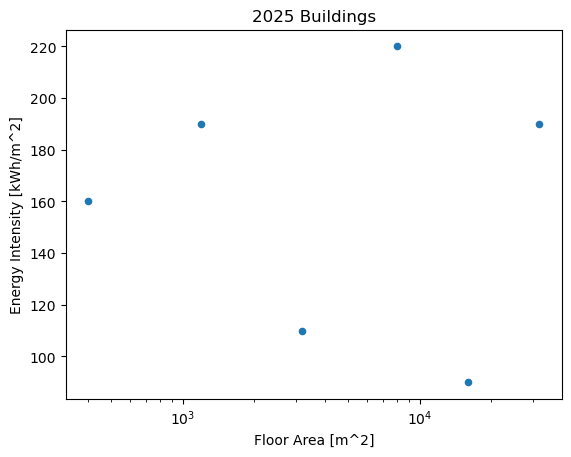

In [10]:
# Your scatterplot here
ax = latest.plot.scatter(x = "floor_area_m2", y = "energy_intensity")
ax.set(
    xscale="log",
    xlabel="Floor Area [m^2]",
    ylabel="Energy Intensity [kWh/m^2]",
    title="2025 Buildings"
)
plt.show

### B. Follow one building over time (1 pt)

From the full `energy` table, select the building named in `energy_settings["trend_building"]`.
Sort its rows by year before making a line plot of energy intensity versus year, with a marker
at each observed year. Use a linear year axis.

Describe the trend. Would this plot alone establish that an energy-saving renovation caused
the change? Give one reason for your answer.

**Answer:** As years increase and renovations take place, the energy intensity decreases. This plot alone does not prove that renovations were energy-saving. Number of people working in the building and usage of high-energy devices are two important factors for energy usage.

<function matplotlib.pyplot.show(close=None, block=None)>

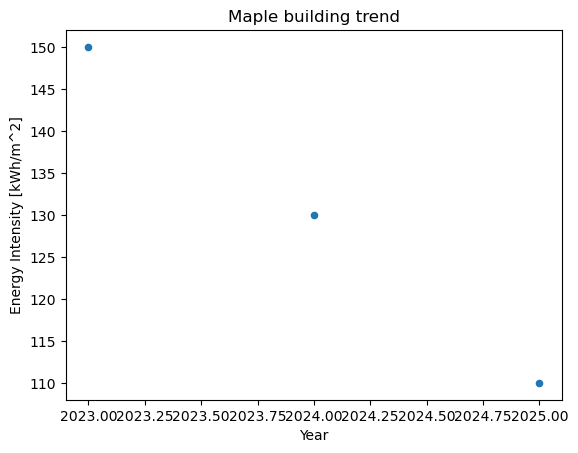

In [11]:
# Your selected, sorted data and time plot here

selected_building = energy.loc[
    (energy["building"] == energy_settings["trend_building"])
].sort_values(by = "year", ascending = True)
ax = selected_building.plot.scatter(x = "year", y = "energy_intensity")
ax.set(
    #xticks=np.arange(2023, 1), #I tried to fix the decimal years but this hid the years instead...and I gave up
    xlabel="Year",
    ylabel="Energy Intensity [kWh/m^2]",
    title="Maple building trend"
)
plt.show

## Session records

At the end of each working session, type **"make my record"** in the chat and paste the block it produces into the cell below. If you work across several sessions, paste each new block underneath the previous one.

<!-- Paste your session record blocks in this cell, one after another. -->

{
  "schema_version": "engr-tutor-export-2",
  "assignment": "WA4",
  "export_n": 1,
  "session_date": "2026-09-29",
  "messages": [
    {"i": 1, "who": "student", "code": true, "text": "can you verify my answer for q 1. A means = calibration.mean()\nbias = means - reference_mm\nprint(means)\n# Your summary table here. Report lengths, s, and estimated bias in mm.\nsummary = pd.DataFrame({\n    \"mean [mm]\": means,\n    \"bias [mm]\": bias,\n    \"sample std [mm]\": calibration.std(ddof = 1).round(3)\n})\ndisplay(summary)\nmarkdown response: Instrument A is more precise because the standard deviation is smaller, meaning less variation in measurements. However instrument B is more accurate because the center of data for measurements is closer to the true reference value of 25 mm."},
    {"i": 2, "who": "tutor", "text": "Confirmed reference values (A mean 25.115, s≈0.016; B mean 25.000, s≈0.073) match the student's approach. Confirmed both written claims (A more precise, B more accurate) are correct, and praised the code (vectorized mean/std, correct bias sign)."},
    {"i": 3, "who": "student", "code": true, "text": "# Your correction and comparison here\ncorrected_A = calibration[\"A_mm\"] - bias[0]\nprint(corrected_A.mean() - reference_mm)\n\ncorrected_A_mean = corrected_A.mean()\ncorrected_A_bias = corrected_A.mean() - reference_mm\ncorrected_A_std = corrected_A.std(ddof = 1)\nsummary.loc[len(summary)] = [\"corrected A\", corrected_A_mean, corrected_A_bias, corrected_A_std]\n\nhow do I add a new row in 1. B?"},
    {"i": 4, "who": "tutor", "text": "Explained .loc[] row-addition syntax generically, then pointed out the value-count mismatch (4 values for a 3-column summary frame, with a label where a number belongs), and offered two fixes without writing the corrected line."},
    {"i": 5, "who": "student", "text": "In 2. A, I'm having trouble with the mask:"},
    {"i": 6, "who": "tutor", "text": "Asked for the current code and what was going wrong (error vs wrong result)."},
    {"i": 7, "who": "student", "code": true, "text": "# Your IQR calculation, Boolean mask, and flagged-reading table here\nq1 = np.quantile(resistance_values, 0.25)\nq3 = np.quantile(resistance_values, 0.75)\niqr = q3 - q1\nmedian = np.quantile(resistance_values, 0.5)\nlower = q1 - resistance_settings[\"outlier_multiplier\"]\nupper = q3 + resistance_settings[\"outlier_multiplier\"]\n\nouter_mask = (resistance_values > upper) | (resistance_values < lower)\nprint(outlier_mask)\ndf_outlier_mask = pd.DataFrame(outlier_mask)\n#print(df_outlier_mask.loc[true])"},
    {"i": 8, "who": "tutor", "text": "Confirmed Q1/Q3 correct. Pointed out the fences use the multiplier on 1.5 directly instead of scaling iqr, and flagged the mask naming mismatch (outlier_mask vs required is_outlier), plus that the display step (loc with reading_id/resistance_ohm/log_status) was still missing."},
    {"i": 9, "who": "student", "code": true, "text": "is_outlier = (resistance_values > upper) | (resistance_values < lower)\nprint(is_outlier)\nreadings.loc[is_outlier]"},
    {"i": 10, "who": "tutor", "text": "Confirmed the .loc[] usage was right, but asked whether the lower/upper fence lines were actually updated since they weren't repasted, and asked whether the display should be restricted to specific columns per the prompt."},
    {"i": 11, "who": "student", "code": true, "text": "for 2.c., i'm confused about observed percentage: # Your observed percentage and normal approximation here\n#make norm fit\nnorm_readings = norm(loc = retained_readings[\"resistance_ohm\"].mean(), scale = retained_readings[\"resistance_ohm\"].std(ddof=1))\n\n#find observed percentage\nis_in_interval = (readings[\"resistance_ohm\"] >= resistance_settings[\"upper_ohm\"]) | (readings[\"resistance_ohm\"] <= resistance_settings[\"lower_ohm\"])\ninterval_readings = readings[is_in_interval]\nobserve_perc = len(interval_readings)/len(readings[\"resistance_ohm\"])\nprint(observe_perc)\n\n#find norm percentage\nnorm_perc = norm_readings.cdf(resistance_settings[\"upper_ohm\"]) - norm_readings.cdf(resistance_settings[\"lower_ohm\"])\nprint(norm_perc)"},
    {"i": 12, "who": "tutor", "text": "Pointed out the mask's comparison operators actually select values outside the interval (at/above upper, at/below lower) rather than inside it, asked which operators and connector (& vs |) would capture 'between', and flagged that the mask was built on readings instead of retained_readings, plus proportion vs percentage."},
    {"i": 13, "who": "student", "code": true, "text": "can you validate question 3.a. : # Your derived column, latest-year selection, and display here\nenergy = buildings.assign(energy_intensity = buildings[\"electricity_kWh\"]/buildings[\"floor_area_m2\"])\ndisplay(energy)\nlatest = buildings[\"year\"].max()\nprint(latest)\nlatest_buildings = energy[(energy[\"year\"] == latest)]"},
    {"i": 14, "who": "tutor", "text": "Viewed buildings.csv to verify. Confirmed ratio direction and .assign() usage and computed-latest-year logic were correct. Flagged that latest was reused as the year integer rather than the required frame name, that latest_buildings had no .copy(), and that the display call showed the full multi-year energy table instead of the four-column latest-year snapshot."},
    {"i": 15, "who": "student", "text": "I have six rows in latest, is this correct?"},
    {"i": 16, "who": "tutor", "text": "Confirmed six is correct (six distinct buildings, one row per building after filtering to the latest year), and restated the still-open naming/.copy()/display fixes."},
    {"i": 17, "who": "student", "code": true, "text": "for 3.b. : # Your filtered and sorted table here\nfiltered_buildings = latest.loc[(latest[\"floor_area_m2\"] >= 3000) & (latest[\"energy_intensity\"] >= 180), [\"building\", \"use\", \"energy_intensity\"]]\nfiltered_buildings_sorted = filtered_buildings.sort_values(by = \"energy_intensity\", ascending = False)\ndisplay(filtered_buildings_sorted)"},
    {"i": 18, "who": "tutor", "text": "Confirmed the compound .loc[] structure and sort were right. Flagged that intensity should use > not >= per the printed threshold, and that 3000/180 should come from energy_settings rather than being hard-coded."},
    {"i": 19, "who": "student", "code": true, "text": "can you explain .groupby for part c : # Your grouped summary here\nbuilding_type = latest.groupby([\"use\"]).agg([\"mean\"])\ndisplay(building_type)"},
    {"i": 20, "who": "tutor", "text": "Explained .groupby()/.agg() generically with a toy example, covering dict vs list vs named-aggregation forms and .reset_index(), then pointed out the submitted call would average every numeric column and produce no count, asking for a rewrite using named aggregation."},
    {"i": 21, "who": "student", "code": true, "text": "# Your grouped summary here\nbuilding_type = latest.groupby([\"use\"]).agg({\"energy_intensity\":\"mean\"},{\"count\"})\ndisplay(building_type)"},
    {"i": 22, "who": "tutor", "text": "Pointed out {\"count\"} is a set literal, not a valid second argument to .agg(), and asked for a second named aggregation using size/count of a column."},
    {"i": 23, "who": "student", "code": true, "text": "# Your grouped summary here\nbuilding_type = latest.groupby([\"use\"]).agg(\n    mean_energy_intensity = (\"energy_intensity\",\"mean\"),\n    number_of_buildings = (\"use\",\"count\"))\ndisplay(building_type)"},
    {"i": 24, "who": "tutor", "text": "Confirmed the two named aggregations were correct and gave the two required columns, grouped on the full latest table. Noted the count-on-'use' works because 'use' is the grouping key and never missing, but flagged 'size' as the generally safer habit. Reminded that the written weighting/larger-mean answer for 3C was still open."},
    {"i": 25, "who": "student", "code": true, "text": "could you debug 4. a. : # Your scatterplot here\nax = latest_buildings.plot.scatter(latest_buildings[\"floor_area_m2\"], latest_buildings[\"energy_intensity\"])\nax.set(\n    xlabel=\"Floor Area m^2\",\n    ylabel=\"Energy Intensity [kWh/m^2]\",\n    title=\"Vehicle weight and fuel economy\"\n)\nplt.show"},
    {"i": 26, "who": "tutor", "text": "Walked through five separate issues: possibly-stale latest_buildings variable name, passing Series instead of column-name strings to .plot.scatter(), missing ax.set_xscale('log'), a mismatched/leftover title, and plt.show missing its parentheses."},
    {"i": 27, "who": "student", "text": "what is the difference between ax = latest_buildings.plot.scatter and plt.scatter(latest_buildings[\"...etc."},
    {"i": 28, "who": "tutor", "text": "Explained the calling-convention difference between plt.scatter(x_data, y_data) and df.plot.scatter(x=\"col\", y=\"col\"), and how each relates to the fig, ax = plt.subplots() pattern used elsewhere in the notebook."},
    {"i": 29, "who": "student", "text": "make my record"}
  ],
  "events": [
    {"i": 1, "part": "4-1A", "type": "code"},
    {"i": 2, "part": "4-1A", "type": "part_pass"},
    {"i": 3, "part": "4-1B", "type": "code"},
    {"i": 7, "part": "4-2A", "type": "code"},
    {"i": 9, "part": "4-2A", "type": "code"},
    {"i": 11, "part": "4-2C", "type": "code"},
    {"i": 13, "part": "4-3A", "type": "code"},
    {"i": 17, "part": "4-3B", "type": "code"},
    {"i": 19, "part": "4-3C", "type": "explain"},
    {"i": 21, "part": "4-3C", "type": "code"},
    {"i": 23, "part": "4-3C", "type": "code"},
    {"i": 24, "part": "4-3C", "type": "part_pass"},
    {"i": 25, "part": "4-4A", "type": "code"},
    {"i": 27, "part": "4-4A", "type": "explain"}
  ],
  "parts": [
    {"part": "4-1A", "exchanges": 1, "max_tier": 1, "passed": true},
    {"part": "4-1B", "exchanges": 1, "max_tier": 2, "passed": false},
    {"part": "4-2A", "exchanges": 2, "max_tier": 3, "passed": false},
    {"part": "4-2C", "exchanges": 1, "max_tier": 3, "passed": false},
    {"part": "4-3A", "exchanges": 2, "max_tier": 2, "passed": false},
    {"part": "4-3B", "exchanges": 1, "max_tier": 2, "passed": false},
    {"part": "4-3C", "exchanges": 3, "max_tier": 3, "passed": true},
    {"part": "4-4A", "exchanges": 1, "max_tier": 3, "passed": false}
  ],
  "tutor_assessment": [
    "The clearest struggle was 4-3C (.groupby().agg()): it took an explain request plus two failed syntax attempts (a plain list form, then a stray set literal) before the student landed on correct named aggregation. 4-4A also surfaced several stacked issues (stale variable name, .plot.scatter() argument style, missing log scale, mismatched title, missing plt.show() parens) in one debug pass, not yet resolved by session's end.",
    "No release valve or 'I got it' shortcuts were used this session, so there's no sign of the tutoring being bypassed or of repeated escape-hatch use masking an unresolved gap."
  ]
}

## Before you submit

1. **Restart Kernel and Run All Cells** and confirm that every cell runs without errors.
2. Confirm that all calculations, tables, and plots are visible in the saved notebook.
3. Confirm that your written answers are complete and your session record block(s) are pasted above.
4. Save the completed `.ipynb` file.
5. Submit the `.ipynb` file in Canvas.